In [1]:
# ============================================================
# NB3 — MOUTH CNN INFERENCE
# BLOCK 1 — IMPORT LIBRARIES
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn

from torchvision import transforms

In [2]:
# ============================================================
# NB3 — BLOCK 2
# CONFIGURATION + CNN MODEL
# ============================================================

# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# Class names — MUST match training
CLASS_NAMES = [
    "Closed",
    "Talking",
    "Yawn"
]

NUM_CLASSES = len(CLASS_NAMES)

# Image size used during training
IMAGE_SIZE = 128

# Trained model weights
MODEL_PATH = "best_model_yawn.pth"


# ============================================================
# CNN MODEL
# ============================================================

class CustomCNN(nn.Module):

    def __init__(self):

        super().__init__()

        # --------------------------
        # Feature Extractor
        # --------------------------

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )


        # --------------------------
        # Classifier
        # --------------------------

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 16 * 16,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                256,
                NUM_CLASSES
            )
        )


    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


print("CNN architecture defined successfully.")

Device: cuda
CNN architecture defined successfully.


In [3]:
# ============================================================
# NB3 — BLOCK 3
# LOAD TRAINED MODEL
# ============================================================

model = CustomCNN().to(device)

# Load trained weights
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

# Evaluation mode
model.eval()

print("=" * 60)
print("TRAINED MODEL LOADED SUCCESSFULLY")
print("=" * 60)

print("Model       :", MODEL_PATH)
print("Device      :", device)
print("Classes     :", CLASS_NAMES)
print("Image Size  :", f"{IMAGE_SIZE} x {IMAGE_SIZE}")
print("=" * 60)

TRAINED MODEL LOADED SUCCESSFULLY
Model       : best_model_yawn.pth
Device      : cuda
Classes     : ['Closed', 'Talking', 'Yawn']
Image Size  : 128 x 128


In [4]:
# ============================================================
# NB3 — BLOCK 4
# IMAGE PREPROCESSING
# ============================================================

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

print("Image preprocessing pipeline ready.")

Image preprocessing pipeline ready.


In [5]:
# ============================================================
# NB3 — BLOCK 5
# PREDICT ONE IMAGE
# ============================================================

IMAGE_PATH = r"C:\Users\Omswaroop\OneDrive\Desktop\New folder\frames\mouth_dataset\yawning"

# Get the first image from the folder
image_files = [
    f for f in os.listdir(IMAGE_PATH)
    if f.lower().endswith(
        (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    )
]

if len(image_files) == 0:
    raise FileNotFoundError(
        f"No images found in: {IMAGE_PATH}"
    )

image_path = os.path.join(
    IMAGE_PATH,
    image_files[0]
)

print("Testing image:")
print(image_path)


# ------------------------------------------------------------
# Load image
# ------------------------------------------------------------

image = Image.open(image_path).convert("L")


# ------------------------------------------------------------
# Apply same preprocessing as training
# ------------------------------------------------------------

input_tensor = transform(image)

# Add batch dimension
input_tensor = input_tensor.unsqueeze(0)

# Move to GPU
input_tensor = input_tensor.to(device)


# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

with torch.no_grad():

    outputs = model(input_tensor)

    probabilities = torch.softmax(
        outputs,
        dim=1
    )

    confidence, predicted_class = torch.max(
        probabilities,
        dim=1
    )


prediction = CLASS_NAMES[
    predicted_class.item()
]

confidence = confidence.item() * 100


# ------------------------------------------------------------
# Display result
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PREDICTION")
print("=" * 60)

print(f"Prediction : {prediction}")
print(f"Confidence : {confidence:.2f}%")

print("=" * 60)

Testing image:
C:\Users\Omswaroop\OneDrive\Desktop\New folder\frames\mouth_dataset\yawning\1-FemaleNoGlasses-Yawning_f000056.jpg

PREDICTION
Prediction : Yawn
Confidence : 100.00%


In [6]:
# ============================================================
# NB3 — BLOCK 6
# TEST ONE IMAGE FROM EACH CLASS
# ============================================================

CLASS_FOLDERS = {
    "Closed": "mouth_closed",
    "Talking": "talking",
    "Yawn": "yawning"
}

for expected_class, folder_name in CLASS_FOLDERS.items():

    folder_path = os.path.join(
        r"C:\Users\Omswaroop\OneDrive\Desktop\New folder\frames\mouth_dataset",
        folder_name
    )

    image_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        )
    ]

    if not image_files:
        print(f"No images found for {expected_class}")
        continue

    image_path = os.path.join(
        folder_path,
        image_files[0]
    )

    image = Image.open(
        image_path
    ).convert("L")

    input_tensor = transform(image)

    input_tensor = input_tensor.unsqueeze(0).to(device)

    with torch.no_grad():

        outputs = model(input_tensor)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, predicted_class = torch.max(
            probabilities,
            dim=1
        )

    prediction = CLASS_NAMES[
        predicted_class.item()
    ]

    confidence = confidence.item() * 100

    print(
        f"Expected: {expected_class:8s} | "
        f"Predicted: {prediction:8s} | "
        f"Confidence: {confidence:.2f}%"
    )

Expected: Closed   | Predicted: Closed   | Confidence: 100.00%
Expected: Talking  | Predicted: Closed   | Confidence: 100.00%
Expected: Yawn     | Predicted: Yawn     | Confidence: 100.00%


In [7]:
# ============================================================
# NB3 — BLOCK 7
# RANDOM TEST — 100 IMAGES PER CLASS
# ============================================================

import random

DATASET_ROOT = r"C:\Users\Omswaroop\OneDrive\Desktop\New folder\frames\mouth_dataset"

SAMPLES_PER_CLASS = 100

random.seed(42)

results = []


for expected_class, folder_name in CLASS_FOLDERS.items():

    folder_path = os.path.join(
        DATASET_ROOT,
        folder_name
    )

    image_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        )
    ]

    # Randomly select images
    sample_size = min(
        SAMPLES_PER_CLASS,
        len(image_files)
    )

    selected_files = random.sample(
        image_files,
        sample_size
    )

    print(
        f"\nTesting {sample_size} {expected_class} images..."
    )

    for filename in selected_files:

        image_path = os.path.join(
            folder_path,
            filename
        )

        image = Image.open(
            image_path
        ).convert("L")

        input_tensor = transform(image)

        input_tensor = (
            input_tensor
            .unsqueeze(0)
            .to(device)
        )

        with torch.no_grad():

            outputs = model(input_tensor)

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            predicted_index = torch.argmax(
                probabilities,
                dim=1
            ).item()

        predicted_class = CLASS_NAMES[
            predicted_index
        ]

        results.append({
            "expected": expected_class,
            "predicted": predicted_class
        })


# ============================================================
# RESULTS
# ============================================================

print("\n" + "=" * 70)
print("RANDOM TEST RESULTS")
print("=" * 70)

total_correct = 0
total_images = len(results)

for class_name in CLASS_NAMES:

    class_results = [
        r for r in results
        if r["expected"] == class_name
    ]

    correct = sum(
        r["predicted"] == class_name
        for r in class_results
    )

    total = len(class_results)

    accuracy = (
        100 * correct / total
        if total > 0
        else 0
    )

    total_correct += correct

    print(
        f"{class_name:8s} : "
        f"{correct}/{total} correct "
        f"({accuracy:.2f}%)"
    )


overall_accuracy = (
    100 * total_correct / total_images
)

print("-" * 70)

print(
    f"Overall : "
    f"{total_correct}/{total_images} "
    f"({overall_accuracy:.2f}%)"
)

print("=" * 70)


Testing 100 Closed images...

Testing 100 Talking images...

Testing 100 Yawn images...

RANDOM TEST RESULTS
Closed   : 99/100 correct (99.00%)
Talking  : 82/100 correct (82.00%)
Yawn     : 100/100 correct (100.00%)
----------------------------------------------------------------------
Overall : 281/300 (93.67%)


MISCLASSIFIED TALKING IMAGES
Found 50 misclassified Talking images.


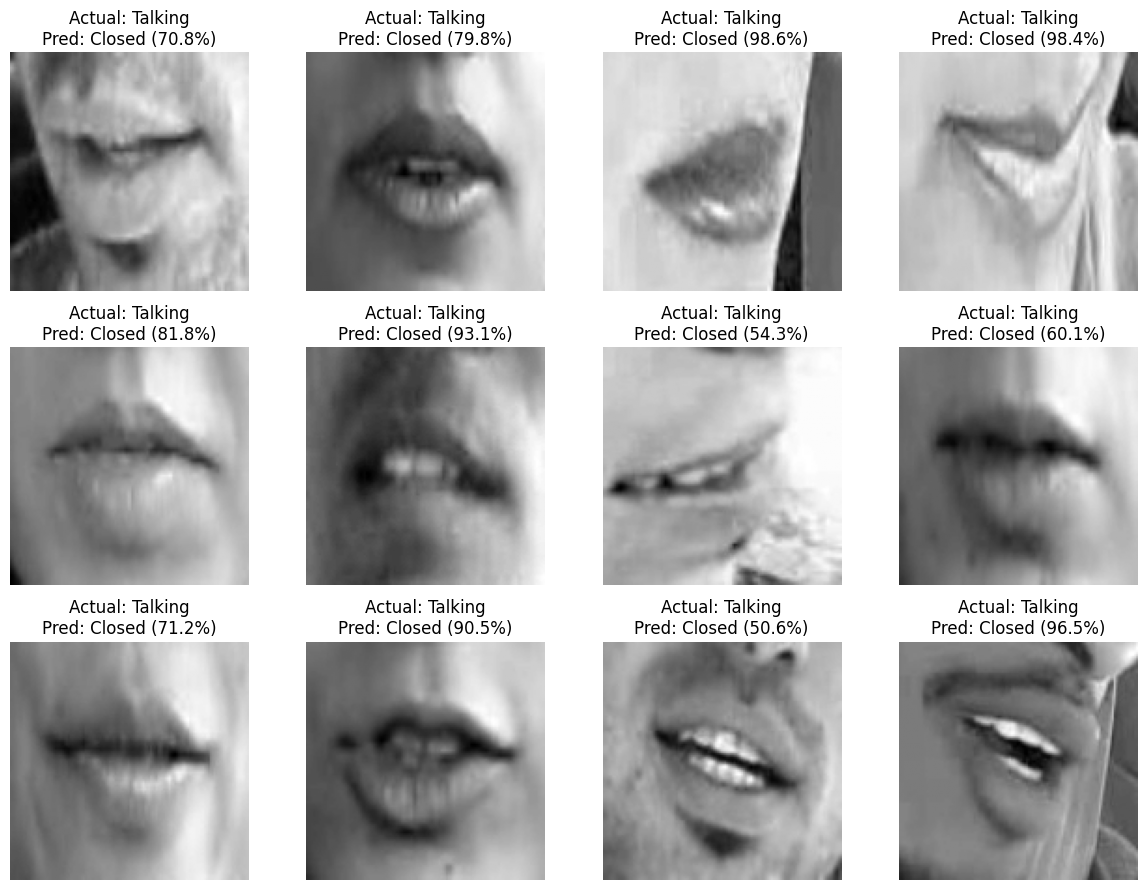

In [8]:
# ============================================================
# NB3 — BLOCK 8
# SHOW MISCLASSIFIED TALKING IMAGES
# ============================================================

import math

wrong_talking = []

talking_folder = os.path.join(
    DATASET_ROOT,
    "talking"
)

talking_files = [
    f for f in os.listdir(talking_folder)
    if f.lower().endswith(
        (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    )
]

# Test up to 300 random Talking images
random.seed(123)

selected_talking = random.sample(
    talking_files,
    min(300, len(talking_files))
)


for filename in selected_talking:

    image_path = os.path.join(
        talking_folder,
        filename
    )

    image = Image.open(
        image_path
    ).convert("L")

    input_tensor = transform(image)

    input_tensor = (
        input_tensor
        .unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():

        outputs = model(input_tensor)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predicted_index = torch.argmax(
            probabilities,
            dim=1
        ).item()

    predicted_class = CLASS_NAMES[
        predicted_index
    ]

    if predicted_class != "Talking":

        confidence = (
            probabilities[0, predicted_index].item()
            * 100
        )

        wrong_talking.append(
            (
                image_path,
                predicted_class,
                confidence
            )
        )


print("=" * 60)
print("MISCLASSIFIED TALKING IMAGES")
print("=" * 60)

print(
    f"Found {len(wrong_talking)} misclassified "
    f"Talking images."
)


# ============================================================
# DISPLAY FIRST 12
# ============================================================

num_images = min(
    12,
    len(wrong_talking)
)

if num_images == 0:

    print("No misclassified Talking images found.")

else:

    cols = 4
    rows = math.ceil(
        num_images / cols
    )

    plt.figure(
        figsize=(12, 3 * rows)
    )

    for i in range(num_images):

        image_path, predicted, confidence = (
            wrong_talking[i]
        )

        image = Image.open(
            image_path
        ).convert("L")

        plt.subplot(
            rows,
            cols,
            i + 1
        )

        plt.imshow(
            image,
            cmap="gray"
        )

        plt.title(
            f"Actual: Talking\n"
            f"Pred: {predicted} ({confidence:.1f}%)"
        )

        plt.axis("off")

    plt.tight_layout()

    plt.show()

In [9]:
# ============================================================
# NB3 — BLOCK 9
# INITIALIZE MEDIAPIPE FACE LANDMARKER
# ============================================================

import mediapipe as mp

from mediapipe.tasks import python
from mediapipe.tasks.python import vision


# ============================================================
# PATH
# ============================================================

MEDIAPIPE_MODEL_PATH = (
    r"C:\Users\Omswaroop\OneDrive\Desktop\New folder"
    r"\face_landmarker.task"
)


# ============================================================
# VERIFY MODEL FILE
# ============================================================

if not os.path.exists(MEDIAPIPE_MODEL_PATH):

    raise FileNotFoundError(
        f"MediaPipe model not found:\n"
        f"{MEDIAPIPE_MODEL_PATH}"
    )


# ============================================================
# CREATE FACE LANDMARKER
# ============================================================

BaseOptions = python.BaseOptions

FaceLandmarker = vision.FaceLandmarker

FaceLandmarkerOptions = vision.FaceLandmarkerOptions

RunningMode = vision.RunningMode


options = FaceLandmarkerOptions(

    base_options=BaseOptions(
        model_asset_path=MEDIAPIPE_MODEL_PATH
    ),

    running_mode=RunningMode.IMAGE,

    num_faces=1
)


detector = FaceLandmarker.create_from_options(
    options
)


print("=" * 60)
print("MEDIAPIPE FACE LANDMARKER LOADED")
print("=" * 60)

print("Model :", MEDIAPIPE_MODEL_PATH)
print("Mode  : IMAGE")
print("Faces : 1")

print("=" * 60)

MEDIAPIPE FACE LANDMARKER LOADED
Model : C:\Users\Omswaroop\OneDrive\Desktop\New folder\face_landmarker.task
Mode  : IMAGE
Faces : 1


In [10]:
# ============================================================
# NB3 — BLOCK 10
# MOUTH LANDMARKS + MOUTH CROPPING
# ============================================================

MOUTH_POINTS = [
    61, 146, 91, 181, 84,
    17, 314, 405, 321, 375,
    291, 409, 270, 269, 267,
    0, 37, 39, 40, 185
]


def crop_mouth(frame):
    """
    Detect the face and crop the mouth region
    using the same method used during training.
    """

    if frame is None:
        return None

    # --------------------------------------------------------
    # OpenCV BGR -> RGB
    # --------------------------------------------------------

    rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    # --------------------------------------------------------
    # Create MediaPipe image
    # --------------------------------------------------------

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    # --------------------------------------------------------
    # Detect face landmarks
    # --------------------------------------------------------

    result = detector.detect(mp_image)

    if not result.face_landmarks:
        return None

    landmarks = result.face_landmarks[0]

    # --------------------------------------------------------
    # Frame dimensions
    # --------------------------------------------------------

    h, w = frame.shape[:2]

    # --------------------------------------------------------
    # Get mouth landmark coordinates
    # --------------------------------------------------------

    pts = np.array([
        (
            int(landmarks[idx].x * w),
            int(landmarks[idx].y * h)
        )
        for idx in MOUTH_POINTS
    ])

    # --------------------------------------------------------
    # Bounding rectangle around mouth
    # --------------------------------------------------------

    x, y, bw, bh = cv2.boundingRect(pts)

    # Same padding used during training
    pad_x = int(bw * 0.30)
    pad_y = int(bh * 0.40)

    # --------------------------------------------------------
    # Crop coordinates
    # --------------------------------------------------------

    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)

    x2 = min(w, x + bw + pad_x)
    y2 = min(h, y + bh + pad_y)

    # --------------------------------------------------------
    # Crop mouth
    # --------------------------------------------------------

    crop = frame[y1:y2, x1:x2]

    if crop.size == 0:
        return None

    # --------------------------------------------------------
    # Resize to CNN input size
    # --------------------------------------------------------

    crop = cv2.resize(
        crop,
        (128, 128),
        interpolation=cv2.INTER_AREA
    )

    return crop

In [11]:
# ============================================================
# NB3 — BLOCK 11
# TEST LIVE MOUTH CROP
# ============================================================

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError("Could not open webcam.")

print("Webcam opened.")
print("Press Q to quit.")


while True:

    ret, frame = cap.read()

    if not ret:
        print("Failed to read webcam frame.")
        break

    # --------------------------------------------------------
    # Detect and crop mouth
    # --------------------------------------------------------

    mouth = crop_mouth(frame)

    # --------------------------------------------------------
    # Display original frame
    # --------------------------------------------------------

    display_frame = frame.copy()

    if mouth is not None:

        # Put text on original frame
        cv2.putText(
            display_frame,
            "Mouth detected",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2
        )

        # Display mouth crop in a separate window
        cv2.imshow(
            "Mouth Crop",
            mouth
        )

    else:

        cv2.putText(
            display_frame,
            "Face/Mouth not detected",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 0, 255),
            2
        )

    cv2.imshow(
        "Webcam",
        display_frame
    )

    # Q = quit
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break


cap.release()
cv2.destroyAllWindows()

print("Webcam test finished.")

Webcam opened.
Press Q to quit.
Webcam test finished.


In [13]:
# ============================================================
# NB3 — BLOCK 12
# LIVE MOUTH STATE PREDICTION
# ============================================================

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError("Could not open webcam.")

print("Live prediction started.")
print("Press Q to quit.")


while True:

    ret, frame = cap.read()

    if not ret:
        print("Failed to read webcam frame.")
        break

    # --------------------------------------------------------
    # MOUTH DETECTION + CROP
    # --------------------------------------------------------

    mouth = crop_mouth(frame)

    prediction = "No mouth detected"
    confidence = 0.0

    if mouth is not None:

        # ----------------------------------------------------
        # Convert OpenCV BGR mouth crop to PIL
        # ----------------------------------------------------

        mouth_rgb = cv2.cvtColor(
            mouth,
            cv2.COLOR_BGR2RGB
        )

        mouth_pil = Image.fromarray(
            mouth_rgb
        ).convert("L")

        # ----------------------------------------------------
        # Same preprocessing used during training
        # ----------------------------------------------------

        input_tensor = transform(
            mouth_pil
        )

        input_tensor = (
            input_tensor
            .unsqueeze(0)
            .to(device)
        )

        # ----------------------------------------------------
        # CNN prediction
        # ----------------------------------------------------

        with torch.no_grad():

            outputs = model(
                input_tensor
            )

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            confidence, predicted_index = torch.max(
                probabilities,
                dim=1
            )

        prediction = CLASS_NAMES[
            predicted_index.item()
        ]

        confidence = (
            confidence.item() * 100
        )

        # ----------------------------------------------------
        # Display mouth crop
        # ----------------------------------------------------

        cv2.imshow(
            "Mouth Crop",
            mouth
        )

    # --------------------------------------------------------
    # DISPLAY PREDICTION ON CAMERA
    # --------------------------------------------------------

    if mouth is not None:

        text = (
            f"{prediction} "
            f"({confidence:.1f}%)"
        )

        cv2.putText(
            frame,
            text,
            (20, 45),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.1,
            (0, 255, 0),
            3
        )

    else:

        cv2.putText(
            frame,
            prediction,
            (20, 45),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 0, 255),
            2
        )

    # --------------------------------------------------------
    # SHOW CAMERA
    # --------------------------------------------------------

    cv2.imshow(
        "Live Mouth CNN",
        frame
    )

    # --------------------------------------------------------
    # QUIT
    # --------------------------------------------------------

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break


cap.release()

cv2.destroyAllWindows()

print("Live prediction stopped.")

Live prediction started.
Press Q to quit.
Live prediction stopped.


In [14]:
# ============================================================
# NB3 — BLOCK 13
# LIVE CNN + TEMPORAL SMOOTHING
# ============================================================

from collections import deque, Counter

# Number of recent predictions to remember
HISTORY_SIZE = 20

prediction_history = deque(
    maxlen=HISTORY_SIZE
)


cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError("Could not open webcam.")

print("Live prediction with smoothing started.")
print("Press Q to quit.")


while True:

    ret, frame = cap.read()

    if not ret:
        print("Failed to read webcam frame.")
        break


    # ========================================================
    # MOUTH DETECTION
    # ========================================================

    mouth = crop_mouth(frame)


    if mouth is not None:

        # ----------------------------------------------------
        # Convert mouth crop to grayscale
        # ----------------------------------------------------

        mouth_rgb = cv2.cvtColor(
            mouth,
            cv2.COLOR_BGR2RGB
        )

        mouth_pil = Image.fromarray(
            mouth_rgb
        ).convert("L")


        # ----------------------------------------------------
        # Same preprocessing used during training
        # ----------------------------------------------------

        input_tensor = transform(
            mouth_pil
        )

        input_tensor = (
            input_tensor
            .unsqueeze(0)
            .to(device)
        )


        # ----------------------------------------------------
        # CNN prediction
        # ----------------------------------------------------

        with torch.no_grad():

            outputs = model(
                input_tensor
            )

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            predicted_index = torch.argmax(
                probabilities,
                dim=1
            ).item()

            confidence = (
                probabilities[0, predicted_index]
                .item() * 100
            )


        current_prediction = CLASS_NAMES[
            predicted_index
        ]


        # ----------------------------------------------------
        # Add prediction to history
        # ----------------------------------------------------

        prediction_history.append(
            current_prediction
        )


        # ----------------------------------------------------
        # Find most common recent prediction
        # ----------------------------------------------------

        most_common = Counter(
            prediction_history
        ).most_common(1)[0]

        smoothed_prediction = most_common[0]

        smoothed_count = most_common[1]


        # ----------------------------------------------------
        # Display mouth
        # ----------------------------------------------------

        cv2.imshow(
            "Mouth Crop",
            mouth
        )


        # ----------------------------------------------------
        # Display current + smoothed prediction
        # ----------------------------------------------------

        cv2.putText(
            frame,
            f"Current: {current_prediction} "
            f"({confidence:.1f}%)",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2
        )

        cv2.putText(
            frame,
            f"Smoothed: {smoothed_prediction}",
            (20, 75),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9,
            (255, 255, 0),
            2
        )

        cv2.putText(
            frame,
            f"History: {smoothed_count}/{len(prediction_history)}",
            (20, 110),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2
        )


    else:

        cv2.putText(
            frame,
            "Face/Mouth not detected",
            (20, 45),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9,
            (0, 0, 255),
            2
        )


    # ========================================================
    # SHOW CAMERA
    # ========================================================

    cv2.imshow(
        "Live Mouth CNN - Smoothed",
        frame
    )


    # ========================================================
    # QUIT
    # ========================================================

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break


cap.release()

cv2.destroyAllWindows()

print("Live prediction stopped.")

Live prediction with smoothing started.
Press Q to quit.
Live prediction stopped.


In [15]:
# ============================================================
# NB3 — BLOCK 14
# LIVE CNN + TEMPORAL SMOOTHING + DROWSINESS SCORE
# ============================================================

from collections import deque, Counter

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

HISTORY_SIZE = 20

# Number of recent Yawn predictions required
# before increasing the score significantly
YAWN_THRESHOLD = 10

# Maximum score
MAX_SCORE = 100


# ------------------------------------------------------------
# PREDICTION HISTORY
# ------------------------------------------------------------

prediction_history = deque(
    maxlen=HISTORY_SIZE
)


cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError("Could not open webcam.")

print("Live drowsiness prototype started.")
print("Press Q to quit.")


while True:

    ret, frame = cap.read()

    if not ret:
        print("Failed to read webcam frame.")
        break


    # ========================================================
    # MOUTH DETECTION
    # ========================================================

    mouth = crop_mouth(frame)


    if mouth is not None:

        # ----------------------------------------------------
        # Convert BGR → RGB → Grayscale
        # ----------------------------------------------------

        mouth_rgb = cv2.cvtColor(
            mouth,
            cv2.COLOR_BGR2RGB
        )

        mouth_pil = Image.fromarray(
            mouth_rgb
        ).convert("L")


        # ----------------------------------------------------
        # SAME PREPROCESSING AS TRAINING
        # ----------------------------------------------------

        input_tensor = transform(
            mouth_pil
        )

        input_tensor = (
            input_tensor
            .unsqueeze(0)
            .to(device)
        )


        # ----------------------------------------------------
        # CNN PREDICTION
        # ----------------------------------------------------

        with torch.no_grad():

            outputs = model(
                input_tensor
            )

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            predicted_index = torch.argmax(
                probabilities,
                dim=1
            ).item()

            confidence = (
                probabilities[0, predicted_index]
                .item() * 100
            )


        current_prediction = CLASS_NAMES[
            predicted_index
        ]


        # ----------------------------------------------------
        # ADD TO HISTORY
        # ----------------------------------------------------

        prediction_history.append(
            current_prediction
        )


        # ----------------------------------------------------
        # MOST COMMON RECENT PREDICTION
        # ----------------------------------------------------

        if len(prediction_history) > 0:

            most_common = Counter(
                prediction_history
            ).most_common(1)[0]

            smoothed_prediction = most_common[0]

            smoothed_count = most_common[1]

        else:

            smoothed_prediction = "Unknown"
            smoothed_count = 0


        # ----------------------------------------------------
        # COUNT RECENT YAWNS
        # ----------------------------------------------------

        yawn_count = sum(
            prediction == "Yawn"
            for prediction in prediction_history
        )


        # ----------------------------------------------------
        # CALCULATE DROWSINESS SCORE
        # ----------------------------------------------------

        if yawn_count >= YAWN_THRESHOLD:

            # Scale from threshold → maximum
            score = int(
                min(
                    MAX_SCORE,
                    (
                        yawn_count
                        / HISTORY_SIZE
                    ) * 100
                )
            )

        else:

            score = int(
                (
                    yawn_count
                    / YAWN_THRESHOLD
                ) * 30
            )


        score = max(
            0,
            min(MAX_SCORE, score)
        )


        # ----------------------------------------------------
        # DROWSINESS STATUS
        # ----------------------------------------------------

        if score >= 70:

            status = "HIGH DROWSINESS"

        elif score >= 40:

            status = "MODERATE DROWSINESS"

        else:

            status = "LOW DROWSINESS"


        # ----------------------------------------------------
        # SHOW MOUTH
        # ----------------------------------------------------

        cv2.imshow(
            "Mouth Crop",
            mouth
        )


        # ----------------------------------------------------
        # DISPLAY INFORMATION
        # ----------------------------------------------------

        cv2.putText(
            frame,
            f"Current: {current_prediction} "
            f"({confidence:.1f}%)",
            (20, 35),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.75,
            (0, 255, 0),
            2
        )

        cv2.putText(
            frame,
            f"Smoothed: {smoothed_prediction}",
            (20, 70),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 255, 0),
            2
        )

        cv2.putText(
            frame,
            f"Yawns: {yawn_count}/{len(prediction_history)}",
            (20, 105),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2
        )

        cv2.putText(
            frame,
            f"Drowsiness Score: {score}/100",
            (20, 140),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.75,
            (0, 255, 255),
            2
        )

        cv2.putText(
            frame,
            f"Status: {status}",
            (20, 180),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 0, 255) if score >= 70
            else (0, 255, 0),
            2
        )


    else:

        cv2.putText(
            frame,
            "Face/Mouth not detected",
            (20, 45),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9,
            (0, 0, 255),
            2
        )


    # ========================================================
    # SHOW CAMERA
    # ========================================================

    cv2.imshow(
        "Driver Drowsiness Prototype",
        frame
    )


    # ========================================================
    # QUIT
    # ========================================================

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break


cap.release()

cv2.destroyAllWindows()

print("Drowsiness prototype stopped.")

Live drowsiness prototype started.
Press Q to quit.
Drowsiness prototype stopped.
